In [34]:
pip install qubo-solver

/opt/anaconda3/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=50859) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()


Note: you may need to restart the kernel to use updated packages.


In [83]:
import torch
from qubosolver import QUBOInstance
from qubosolver.config import SolverConfig, LocalEmulator
from qubosolver.solver import QuboSolver

# define QUBO
Q = torch.tensor([[-0.2, 0, 1.0], [0, 0,1.5], [1.0, 1.5, 0]])
instance = QUBOInstance(coefficients=Q)

# Create a SolverConfig object to use a quantum backend
config = SolverConfig(use_quantum=True, backend = LocalEmulator())

# Instantiate the quantum solver.
solver = QuboSolver(instance, config)

# Solve the QUBO problem.
solution = solver.solve()

# Display results
print(solution)

QUBOSolution(bitstrings=tensor([[1, 0, 0],
        [0, 0, 1],
        [0, 1, 0],
        [0, 0, 0]], dtype=torch.int32), costs=tensor([-0.2000,  0.0000,  0.0000,  0.0000]), counts=tensor([11, 13, 13, 63]), probabilities=tensor([0.1100, 0.1300, 0.1300, 0.6300]), solution_status=<SolutionStatusType.UNPROCESSED: 'unprocessed'>)


Example of using the QUBO solver. Notice we do not have to "tune" anything quantum, it acts as a black box very similarly to a classical algo. With this solver you can also choose to use classical solvers, or send the QUBO to a real quantum computer (not available on Ruby rn).

Preprocessing and postprocessing are optional techniques that can help in solving QUBOs better. (as it is done in classical state of the art solvers)

Before solving, QUBO preprocessing attempts to reduce the size of the problem before solving, by deterministically fixing variables to 0 or 1 when possible.

After solving, QUBO solutions can be refined by applying a local bit-flip search to each candidate bitstring. It evaluates each modified solution against the original QUBO instance, aiming to lower the objective cost.



When using quantum approaches, we have to define a map from the instance variables to atoms on a quantum device. We call this step an embedding. This tutorial aims to show small code snippet on how to use the different embedding methods (blade, custom, greedy). This is one of the force of the qubo library, in particular the BLADE embedding.

BLaDE (Balanced Latently Dimensional Embedder) is a method designed at PASQAL that allows to find best positions for atoms for a given problem. We say that we embed the problem, and the resulting placement of atoms is called a register or embedding. When atoms have been prepared in the vacuum chamber of the QPU, they can interact with each other when they are close neighbors. When they are set farther apart, the interaction on each pair of atoms decays rapidly. The formula that defines the amplitude of interaction is C_6/R^6
, where C_6
 is a constant that depends on the QPU, and R
 is the distance between two atoms. Given positions for atoms, we name interaction matrix the matrix that contains the amplitude of interaction on each pair of atoms.

When solving a problem on the QPU, in general, we want to target a specific interaction matrix. In particular, when solving a QUBO, we want the interaction matrix to mimic the QUBO matrix, such that each interaction corresponds to a quadratic term of the QUBO.

BLaDE allows to look for the best way to position the atoms, such that the interaction matrix is as close to a target matrix as possible. If the target matrix is a QUBO, it can be used to prepare a register to solve a QUBO. It is an iterative algorithm, that starts from initial positions (e.g. random positions). Then, at each step, it moves points using "forces" to make each interaction get closer to the corresponding quadratic term. In that matter, it takes inspiration from the Fruchterman-Reingold algorithm.



Lots of potential tuning for this embedder that will not be covered today.

In [84]:
from qubosolver.algorithms.blade.blade import em_blade, em_blade_for_device
from qubosolver.algorithms.blade._helpers import interaction_matrix_from_positions, normalized_distance
from qoolqit import AnalogDevice
import numpy as np
from pulser import Register
import matplotlib.pyplot as plt

np.set_printoptions(precision=1, suppress=True)
np.random.seed(0)

# need to take the underlying device AnalogDevice() wraps
device = AnalogDevice()._device
%matplotlib inline

In [85]:
qubo = np.array(
      [[  0.,   3.,  13., 211.,  49.,   5.,  12.,   0.,   0.],
       [  0.,   0.,  23.,   0.,   0.,   4.,   0.,  63.,   2.],
       [  0.,   0.,   0.,   5.,   0.,   1.,   0.,   1.,   0.],
       [  0.,   0.,   0.,   0.,  37.,   0.,   1.,   0.,   0.],
       [  0.,   0.,   0.,   0.,   0.,   1.,  34.,   0.,   0.],
       [  0.,   0.,   0.,   0.,   0.,   0.,  35.,   9.,  34.],
       [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   1.],
       [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,  70.],
       [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.]])

In [86]:
positions = em_blade(qubo)

/opt/anaconda3/lib/python3.12/site-packages/qubosolver/algorithms/blade/_helpers.py:9: RuntimeWarning: divide by zero encountered in divide
  return 1 / dist**6
/opt/anaconda3/lib/python3.12/site-packages/qubosolver/algorithms/blade/_helpers.py:13: RuntimeWarning: divide by zero encountered in divide
  return (1 / weight) ** (1 / 6)  # type: ignore[no-any-return]


In [87]:
interactions = interaction_matrix_from_positions(positions)
interactions

array([[  0. ,   1.1,  14.2, 211.4,  49.2,   5.5,  12.2,   0.3,   0.2],
       [  0. ,   0. ,  23.2,   0.2,   0.1,   4.2,   0.3,  62.7,   1.8],
       [  0. ,   0. ,   0. ,   3.1,   0.4,   1.3,   0.4,   0.7,   0.2],
       [  0. ,   0. ,   0. ,   0. ,  35.9,   0.4,   1.3,   0.1,   0. ],
       [  0. ,   0. ,   0. ,   0. ,   0. ,   1. ,  33.2,   0.1,   0.1],
       [  0. ,   0. ,   0. ,   0. ,   0. ,   0. ,  34.1,   8.3,  34.4],
       [  0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0.3,   0.8],
       [  0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,  70. ],
       [  0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ]])

In [88]:
normalized_distance(target=qubo, actual=interactions)

0.014930194323719994

/opt/anaconda3/lib/python3.12/site-packages/qubosolver/algorithms/blade/_dist_constraints_forces.py:41: RuntimeWarning: invalid value encountered in divide
  max_unitary_vectors = positions / np.linalg.norm(positions, axis=1)[:, np.newaxis]


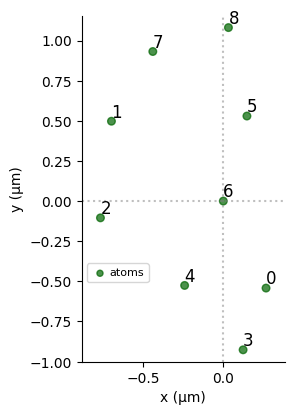

In [89]:
#some small hiccups sometime on the draw() function

positions = em_blade(qubo)
Register({str(i): p for i,p in enumerate(positions)}).draw()

Drive Shaping Methods

A quantum program in the Rydberg analog model is defined as a time-dependent drive Hamiltonian that is imposed on the qubits (in addition to the interaction Hamiltonian). The drive shaping configuration part (the drive_shaping field of SolverConfig) defines how the drive parameters are constructed.

The QUBO solver allows to use adiabatic or optimized drive shaping. Allows for tuning options.

Solving with a decomposition

To solve large QUBO instances using a quantum approach, we can set in SolverConfig the decompose argument to True and set several decomposition hyperparameters. This will use an iterative algorithm that solves a subproblem (found by placing a subset variables heuristically on a device).

In [71]:
from qubosolver import QUBOInstance
from qubosolver.solver import QuboSolver
from qubosolver.config import SolverConfig, DecompositionConfig

In [72]:
import torch

def generate_qubo_matrix(
    size: int, density: float, value_range: tuple[int, int], seed: int | None = None
) -> torch.Tensor:
    """Generate a random symmetric qubo matrix with negative diagonal coefficients
       and positive off-diagonal elements.

    Args:
        size (int): Size of qubo.
        density (float): Density.
        value_range (tuple[int, int]): Value range of elements.
        seed (int | None, optional): Random seed for reproducibility. Defaults to None.

    Returns:
        torch.Tensor: Qubo matrix.
    """

    import numpy as np

    if seed is not None:
        np.random.seed(seed)
    matrix = np.zeros((size, size))
    for i in range(size):
        matrix[i, i] = -np.abs(np.random.uniform(0, 100))  # Negative diagonal
        for j in range(i + 1, size):
            if np.random.rand() < density:
                value = np.abs(
                    np.random.uniform(value_range[0], value_range[1])
                )  # Positive off-diagonal
                matrix[i, j] = value
                matrix[j, i] = value
    return torch.tensor(matrix)

In [73]:
decomposable_qubo = QUBOInstance(generate_qubo_matrix(80, 0.30, (0, 20), 1))

config = SolverConfig(use_quantum=True, decompose=DecompositionConfig())
solver = QuboSolver(decomposable_qubo, config)

In [74]:
solver.solve()

QUBOSolution(bitstrings=tensor([[0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1,
         1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0,
         0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
         0, 0, 1, 1, 0, 0, 0, 0]], dtype=torch.int32), costs=tensor([-564.3189]), counts=tensor([1], dtype=torch.int32), probabilities=None, solution_status=<SolutionStatusType.UNPROCESSED: 'unprocessed'>)

In [75]:
solver._solver.number_iterations

5